# Larger Real-Data Portfolio Example

This notebook uses a 12-stock real-data universe to stress the
package beyond the smaller examples. Binary VQE and QAOA use
one qubit per asset, so this example is intentionally kept at
12 assets rather than treated as a large-scale production run.

Window: `2024-01-01` to `2025-01-01`  
Tickers: `AAPL, MSFT, NVDA, AMZN, GOOGL, META, JPM, XOM, JNJ, PG, HD, UNH`  
Binary cardinality: `K=5`  
Risk-aversion: `lambda=4.0`  
Penalty: `alpha=8.0`

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.generate_larger_real_data_example import main

main(
    [
        "--tickers",
        "AAPL,MSFT,NVDA,AMZN,GOOGL,META,JPM,XOM,JNJ,PG,HD,UNH",
        "--start",
        "2024-01-01",
        "--end",
        "2025-01-01",
        "--lambda",
        "4.0",
        "--alpha",
        "8.0",
        "--k",
        "5",
        "--steps",
        "16",
        "--shots",
        "512",
        "--seed",
        "7",
    ]
)

[{'dataset': 'Larger real data n=12',
  'n_assets': '12',
  'k': '5',
  'method': 'Classical exhaustive search',
  'type': 'classical',
  'lambda': '4',
  'objective_family': 'binary_qubo',
  'reported_weighting': 'equal_weight_selected',
  'seed_count': '1',
  'best_objective': '-0.043286',
  'mean_objective': '-0.043286',
  'std_objective': '0.000000',
  'mean_return': '0.341060',
  'mean_risk': '0.128919',
  'feasible_rate': '1.000000',
  'mean_runtime_seconds': '0.007354',
  'best_selection_or_weights': '101000101100',
  'notes': 'Exact binary cardinality baseline',
  'selected_assets': 'AAPL, NVDA, JPM, JNJ, PG'},
 {'dataset': 'Larger real data n=12',
  'n_assets': '12',
  'k': '5',
  'method': 'Classical top-return heuristic',
  'type': 'classical heuristic',
  'lambda': '4',
  'objective_family': 'binary_qubo',
  'reported_weighting': 'equal_weight_selected',
  'seed_count': '1',
  'best_objective': '2.388722',
  'mean_objective': '2.388722',
  'std_objective': '0.000000',
  'me

In [2]:
csv_path = ROOT / "results" / "larger_real_data_comparison.csv"
rows = pd.read_csv(csv_path)
rows[
    [
        "method",
        "objective_family",
        "k",
        "mean_return",
        "mean_risk",
        "best_objective",
        "feasible_rate",
        "best_selection_or_weights",
        "selected_assets",
    ]
]

,method,objective_family,k,mean_return,mean_risk,best_objective,feasible_rate,best_selection_or_weights,selected_assets
0,Classical exhaustive search,binary_qubo,5.0,0.341060,0.128919,-0.043286,1.000000,101000101100,"AAPL, NVDA, JPM, JNJ, PG"
1,Classical top-return heuristic,binary_qubo,5.0,0.505711,0.221749,2.388722,1.000000,001111100000,"NVDA, AMZN, GOOGL, META, JPM"
2,Classical minimum-variance subset,binary_qubo,5.0,0.115801,0.093688,0.298743,1.000000,110000011100,"AAPL, MSFT, XOM, JNJ, PG"
3,Classical equal weight,fractional_simplex,NaN,0.266671,0.118497,-0.210504,1.000000,[0.083333 0.083333 0.083333 0.083333 0.083333 ...,NaN
4,Classical exact Markowitz,fractional_simplex,NaN,0.580921,0.226857,-0.375066,1.000000,[0.064290 0.000000 0.364721 0.000000 0.000000 ...,NaN
5,Binary VQE best feasible,binary_qubo,5.0,0.257295,0.120824,0.173363,0.777344,001000011110,"NVDA, XOM, JNJ, PG, HD"
6,QAOA X best feasible,binary_qubo,5.0,0.248903,0.117525,0.136706,0.343750,100001100101,"AAPL, META, JPM, PG, UNH"
7,QAOA XY best feasible,binary_qubo,5.0,0.346208,0.172098,1.230733,1.000000,011010100001,"MSFT, NVDA, GOOGL, JPM, UNH"
8,Fractional VQE,fractional_simplex,NaN,0.549606,0.217478,-0.360419,1.000000,[0.044328 0.015962 0.346892 0.007161 0.059064 ...,NaN


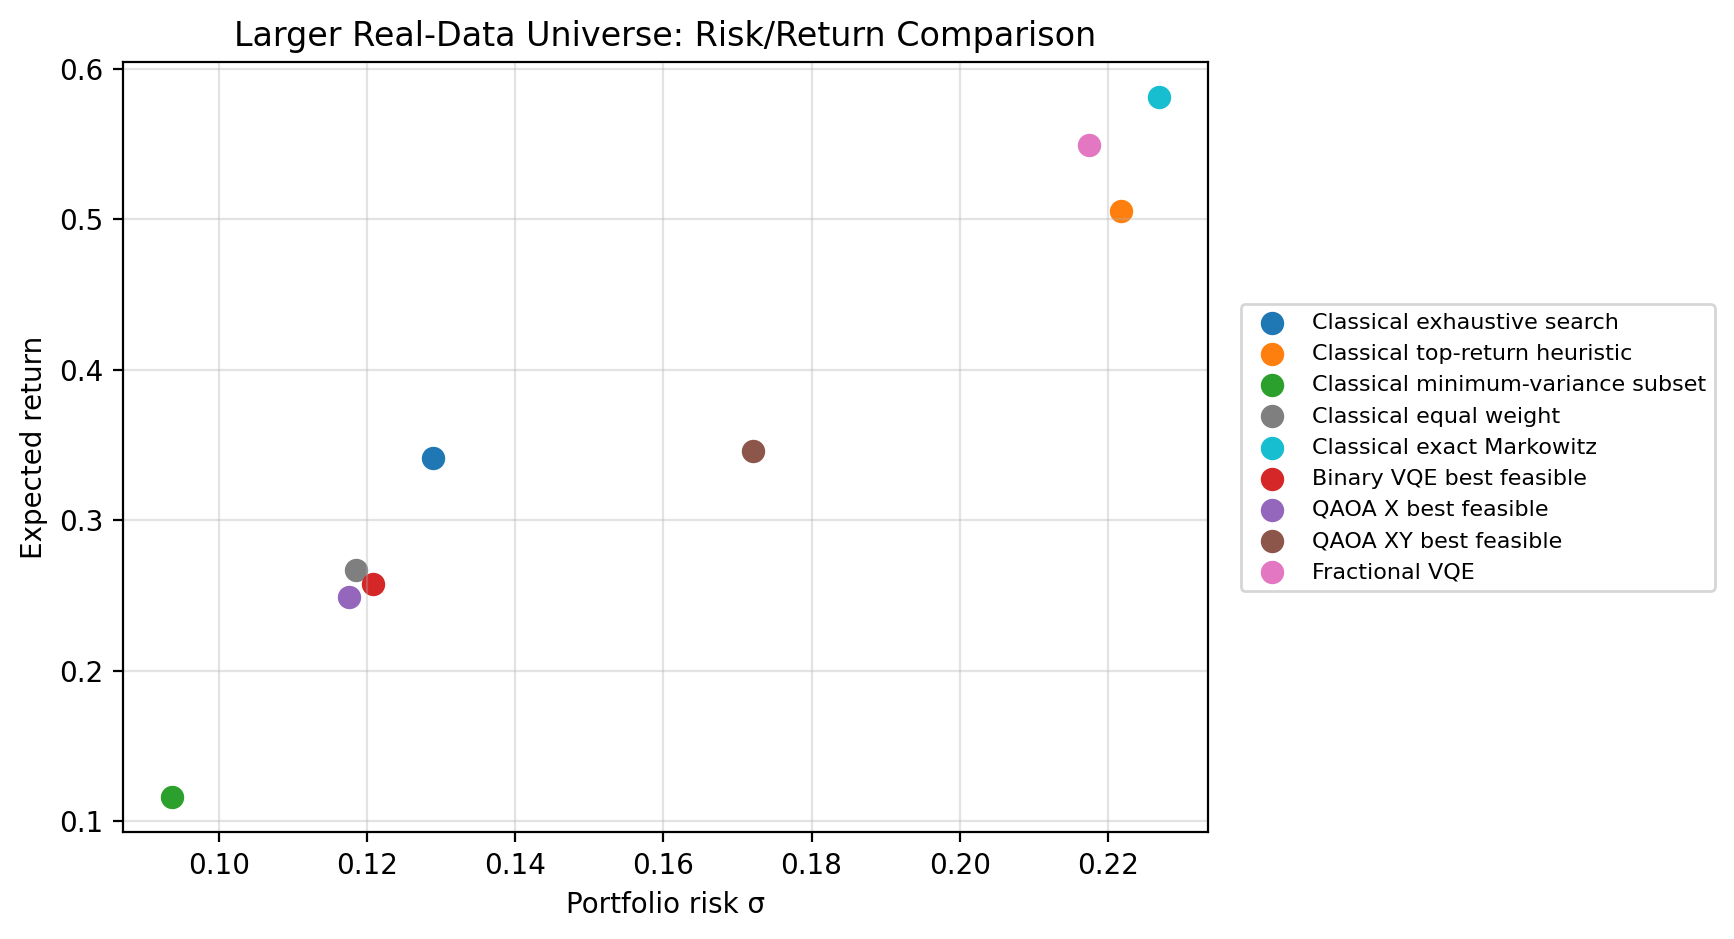

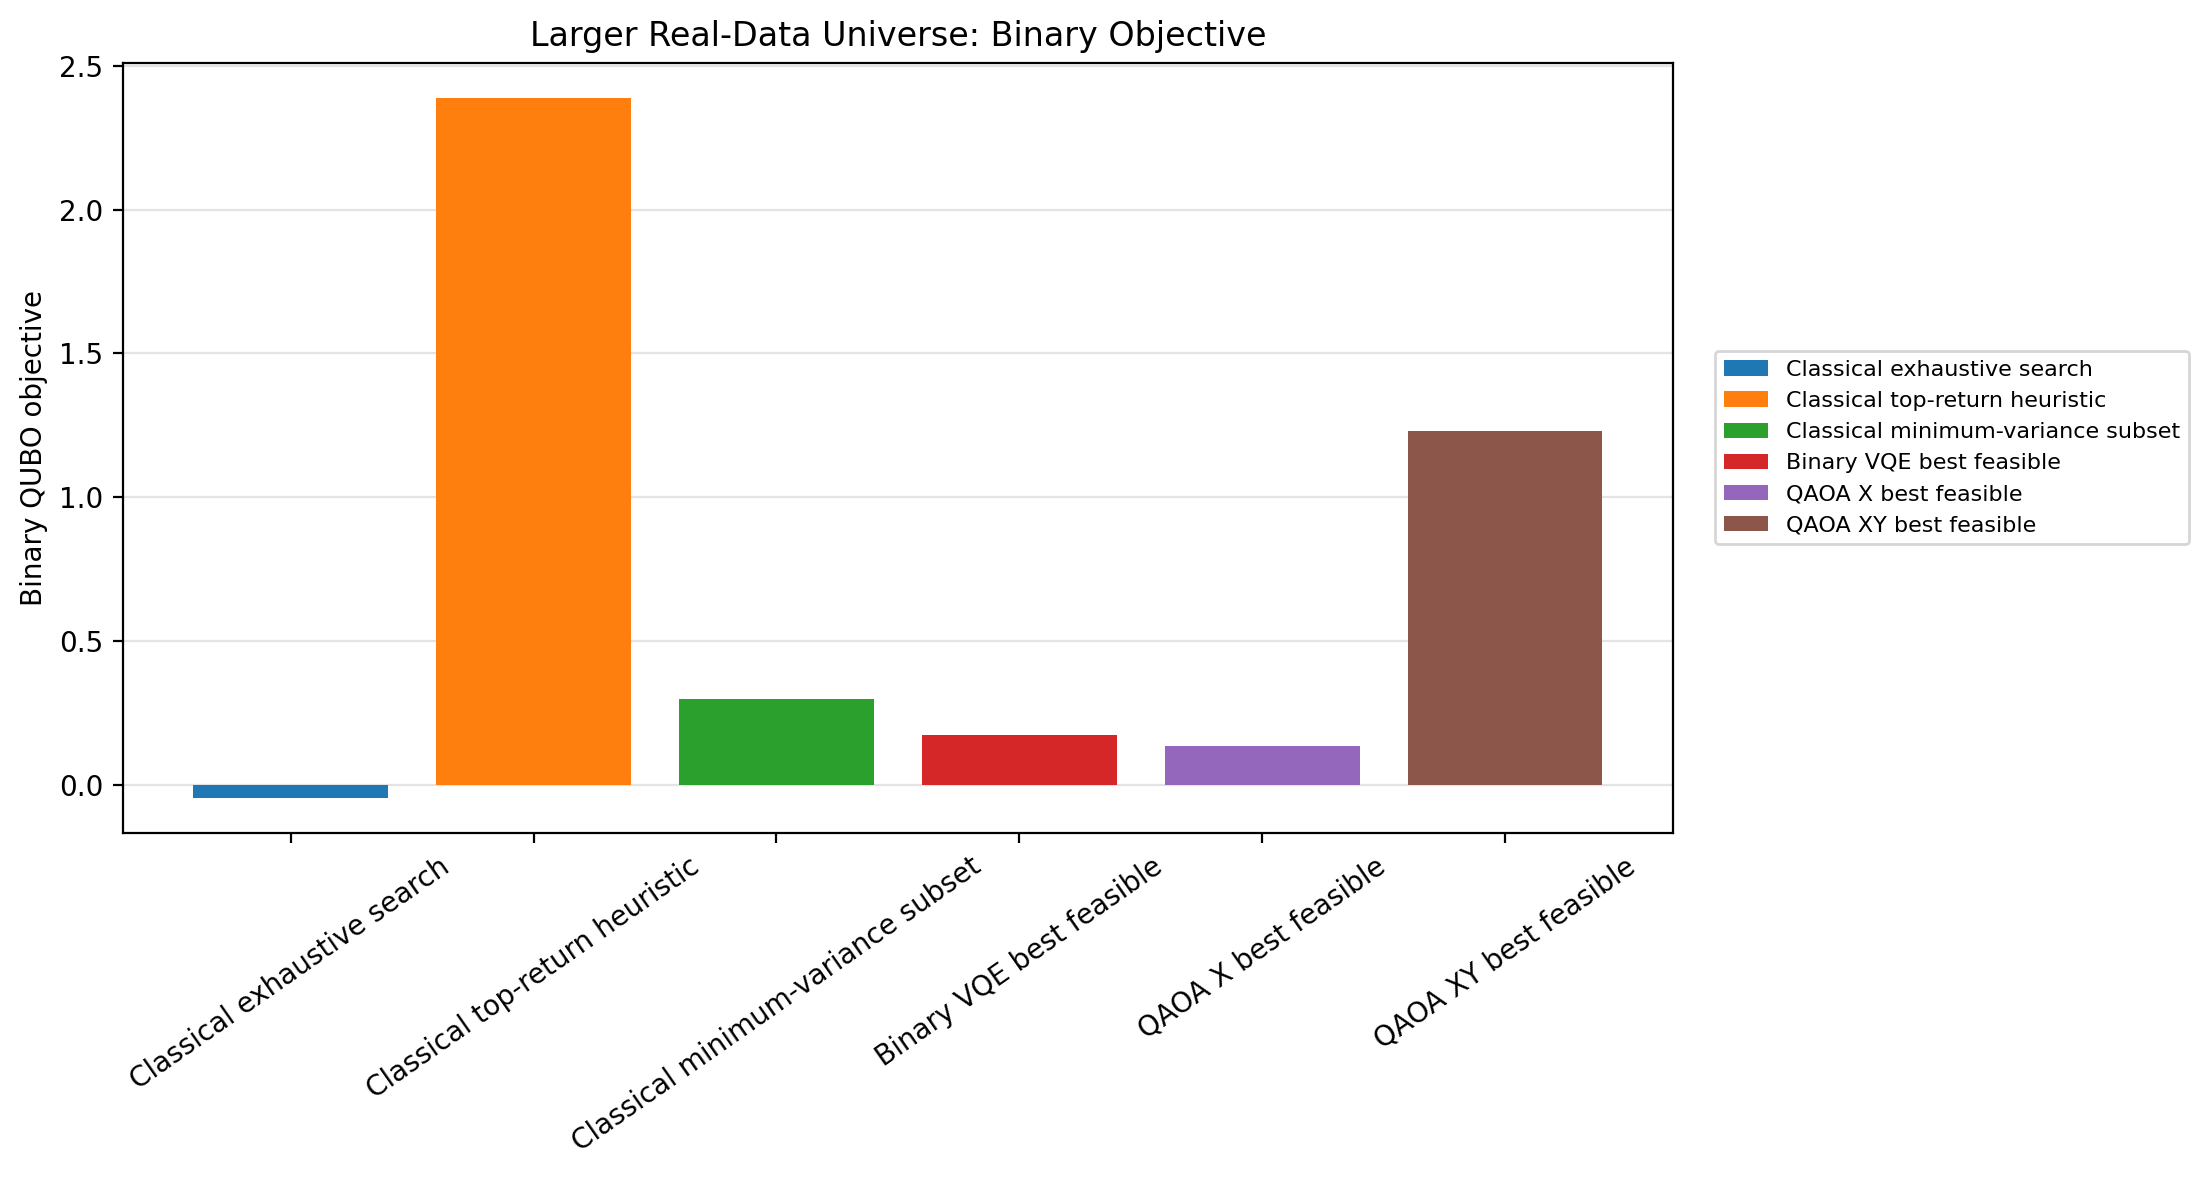

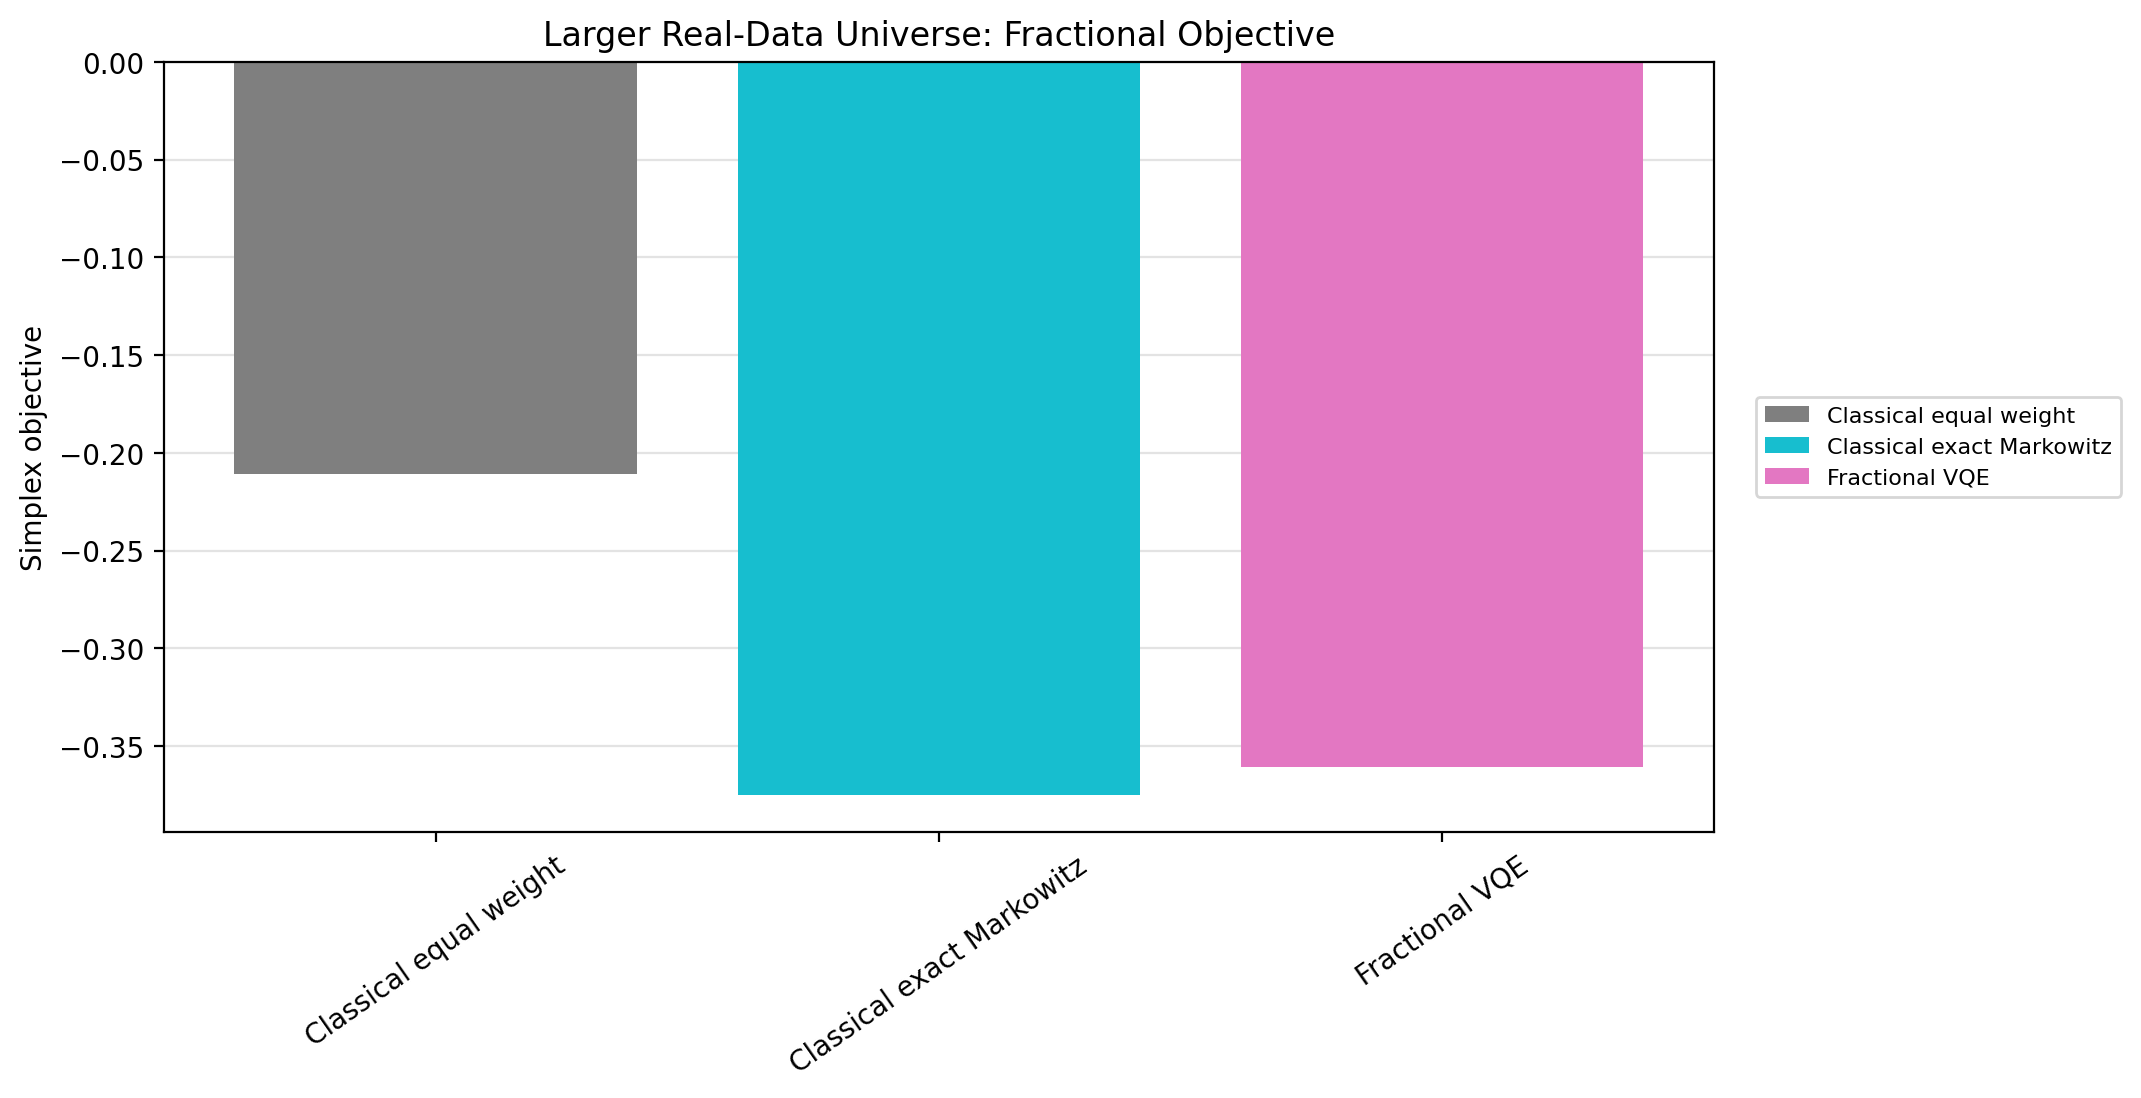

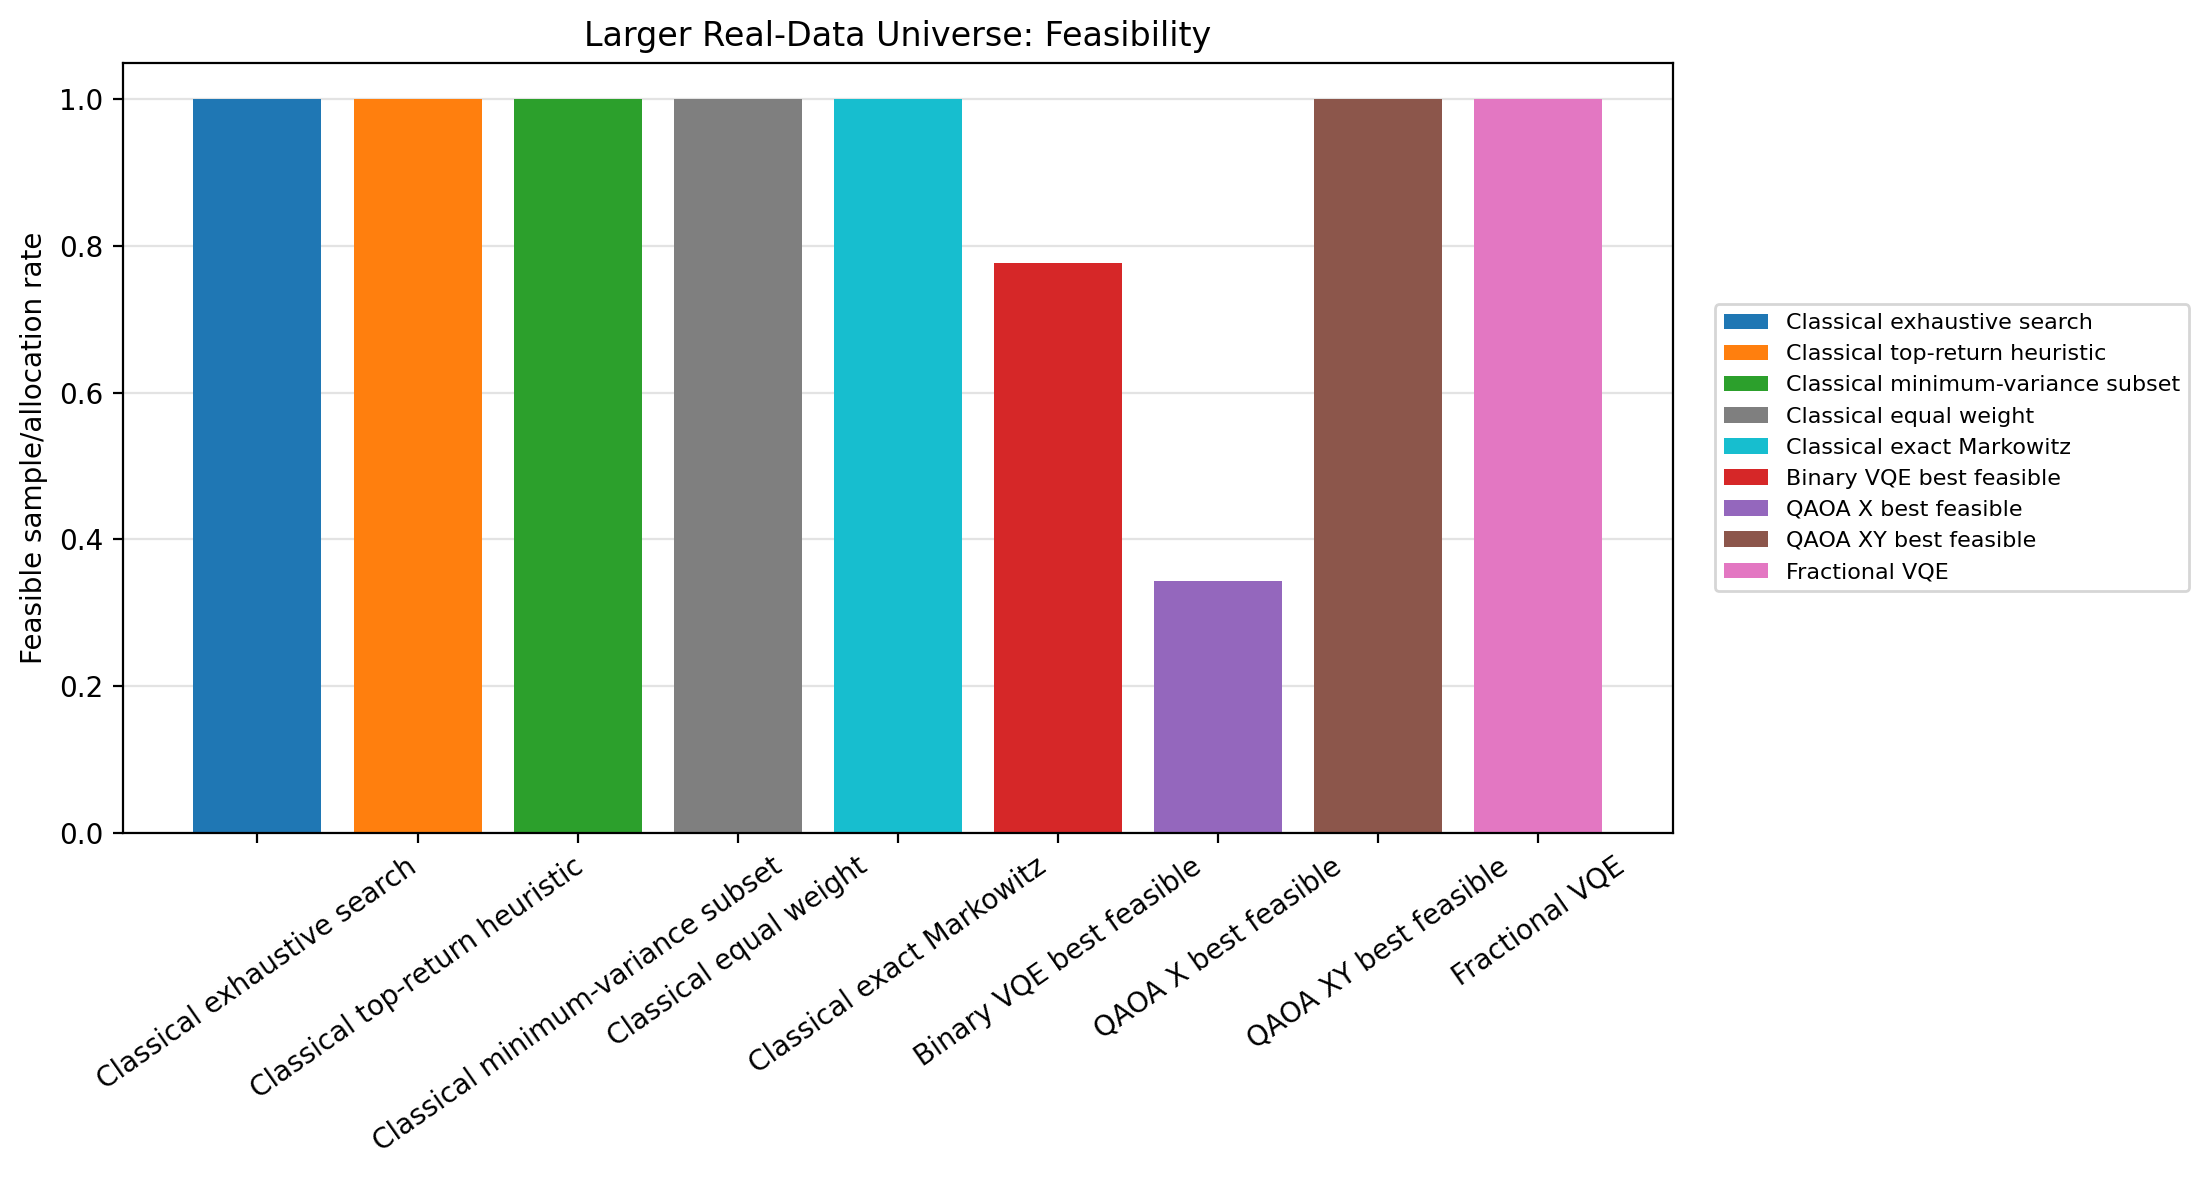

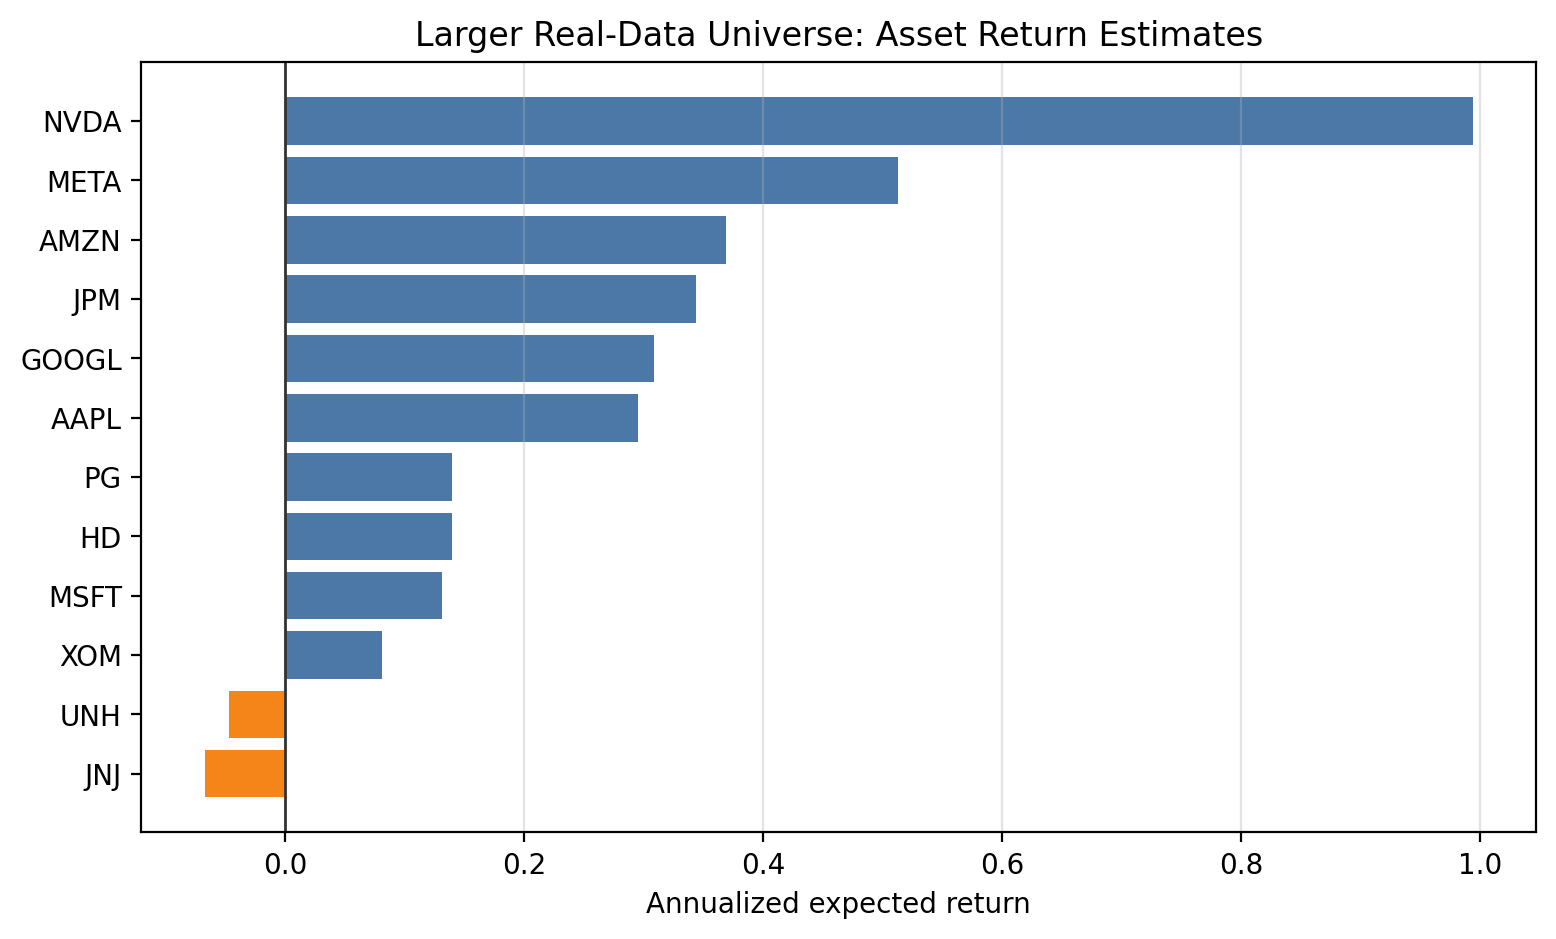

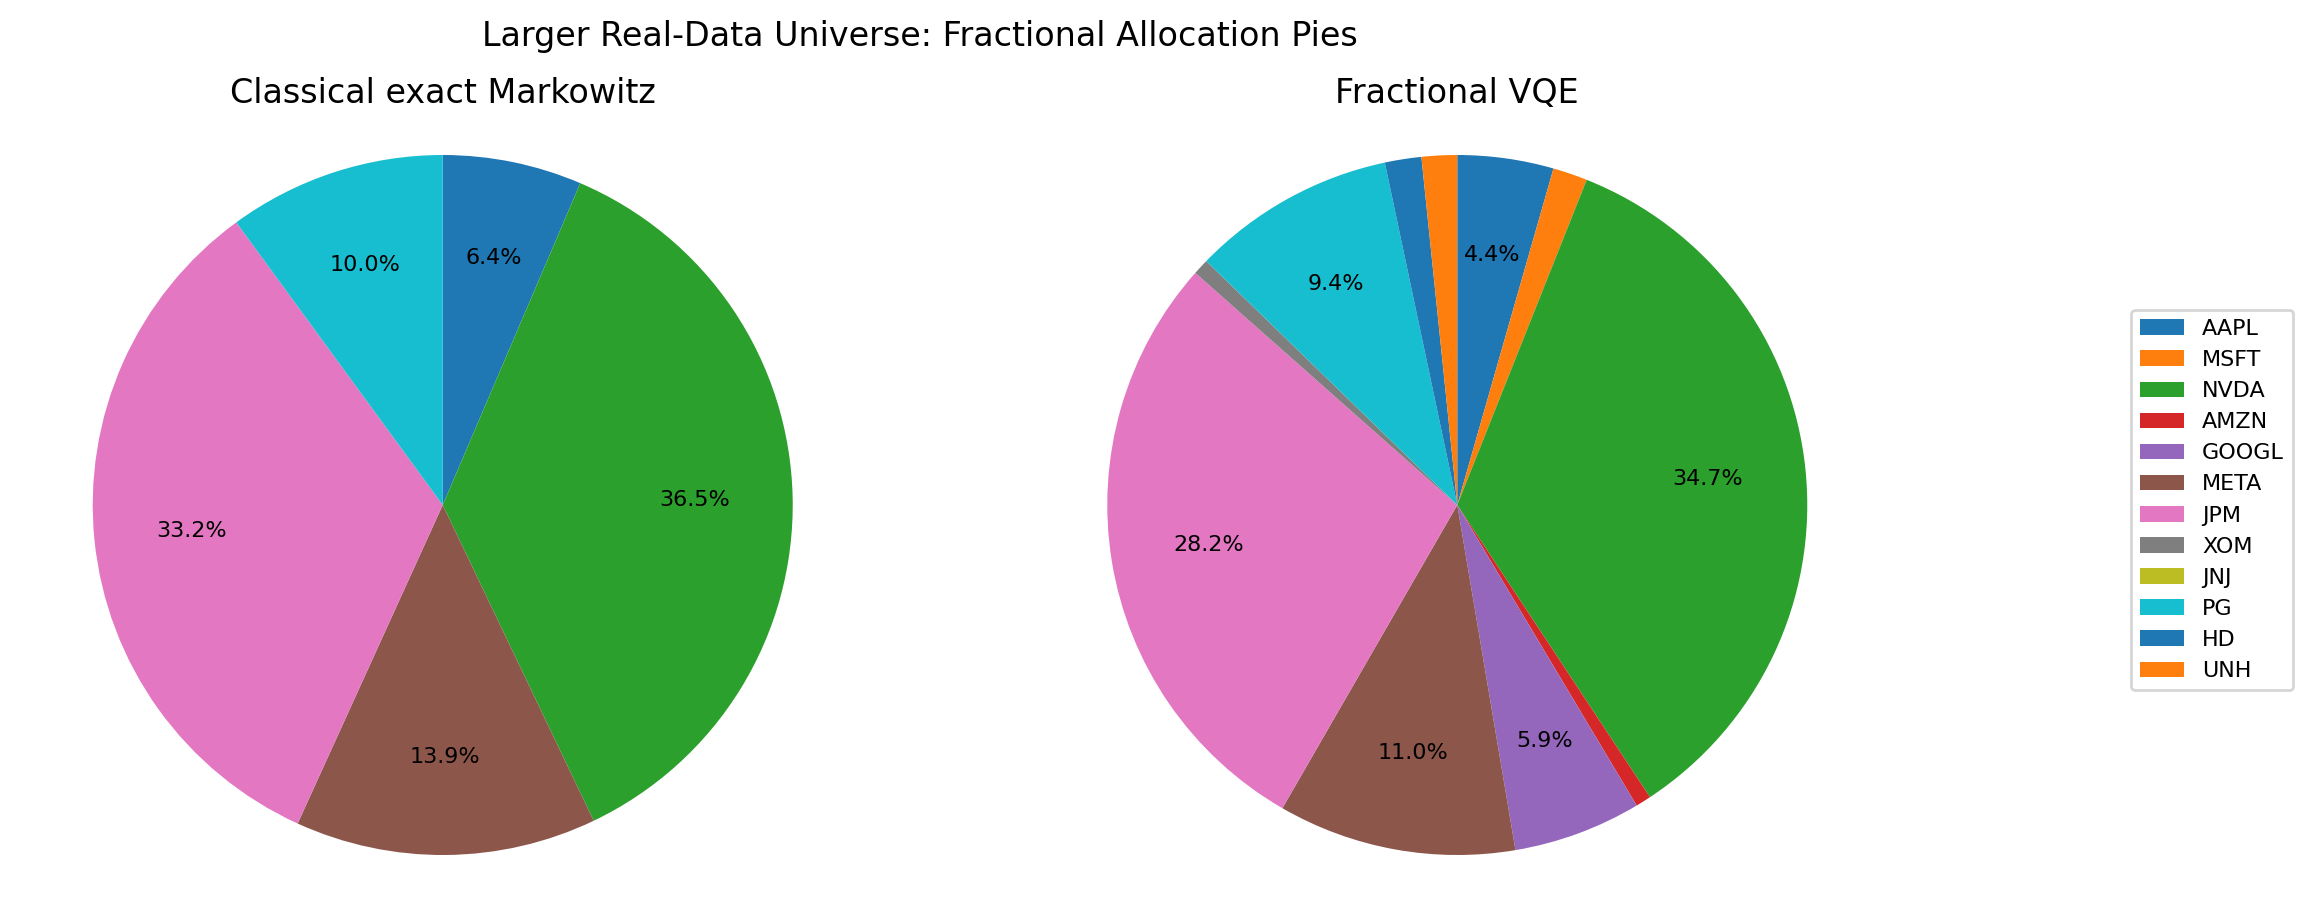

In [3]:
image_paths = [
    "notebooks/examples/images/Larger_Real_Data_Risk_Return.png",
    "notebooks/examples/images/Larger_Real_Data_Binary_Objective.png",
    "notebooks/examples/images/Larger_Real_Data_Fractional_Objective.png",
    "notebooks/examples/images/Larger_Real_Data_Feasibility.png",
    "notebooks/examples/images/Larger_Real_Data_Asset_Returns.png",
    "notebooks/examples/images/Larger_Real_Data_Fractional_Weights.png",
]

for path in image_paths:
    display(Image(filename=str(ROOT / path)))

The binary objective and fractional objective are different
mathematical objectives. Compare methods within each objective
family, and use the risk/return chart as a cross-family view of
the reported portfolios.